<a href="https://colab.research.google.com/github/fmakkawi/Data-205/blob/main/DATA205_Capstone_FarahMakkawi_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project analyzes the relationship between education, income, population, and internet access across Maryland counties. The main goal is to understand how these factors are connected and how they differ between counties, with a focus on comparing Montgomery County and Prince George’s County.

In [1]:
# Farah Makkawi
# DATA 205 Capstone Project

from google.colab import files

uploaded = files.upload()

Saving internet_data.csv to internet_data.csv


In [2]:
from google.colab import files

uploaded = files.upload()

Saving income_data.csv to income_data.csv


In [3]:
from google.colab import files

uploaded = files.upload()

Saving population_data.csv to population_data.csv


In [4]:
from google.colab import files

uploaded = files.upload()

Saving education_data.csv to education_data.csv


In [27]:
import pandas as pd

# Load datasets (IMPORTANT: skiprows=1 for Census files)
income = pd.read_csv("income_data.csv", skiprows=[1])
population = pd.read_csv("population_data.csv", skiprows=[1])
education = pd.read_csv("education_data.csv", skiprows=[1])
internet = pd.read_csv("internet_data.csv", skiprows=[1])

# Check they loaded correctly
print("Income:", income.shape)
print("Population:", population.shape)
print("Education:", education.shape)
print("Internet:", internet.shape)

Income: (24, 131)
Population: (24, 379)
Education: (24, 771)
Internet: (24, 127)


In [28]:
# Select important columns

income_clean = income[["NAME", "S1901_C01_012E"]].rename(columns={
    "S1901_C01_012E": "Median_Income"
})

population_clean = population[["NAME", "DP05_0001E"]].rename(columns={
    "DP05_0001E": "Population"
})

education_clean = education[["NAME", "S1501_C02_015E"]].rename(columns={
    "S1501_C02_015E": "Bachelors_Percent"
})

internet_clean = internet[["NAME", "S2801_C02_014E"]].rename(columns={
    "S2801_C02_014E": "Internet_Access_Percent"
})

# Preview
income_clean.head()

,NAME,Median_Income
0,"Allegany County, Maryland",57393
1,"Anne Arundel County, Maryland",120324
2,"Baltimore County, Maryland",90904
3,"Calvert County, Maryland",132059
4,"Caroline County, Maryland",66368


In [29]:
# Merge all datasets

df = income_clean.merge(population_clean, on="NAME")
df = df.merge(education_clean, on="NAME")
df = df.merge(internet_clean, on="NAME")

# Preview final dataset
df.head()

,NAME,Median_Income,Population,Bachelors_Percent,Internet_Access_Percent
0,"Allegany County, Maryland",57393,67762,21.1,83.8
1,"Anne Arundel County, Maryland",120324,590936,45.2,94.9
2,"Baltimore County, Maryland",90904,849586,41.4,90.5
3,"Calvert County, Maryland",132059,93791,35.3,92.9
4,"Caroline County, Maryland",66368,33406,17.6,86.3


In [30]:
# Filter the two counties

target = df[
    df["NAME"].isin([
        "Montgomery County, Maryland",
        "Prince George's County, Maryland"
    ])
]

target

,NAME,Median_Income,Population,Bachelors_Percent,Internet_Access_Percent
14,"Montgomery County, Maryland",128733,1057586,60.3,95.3
15,"Prince George's County, Maryland",100708,955584,36.1,92.9


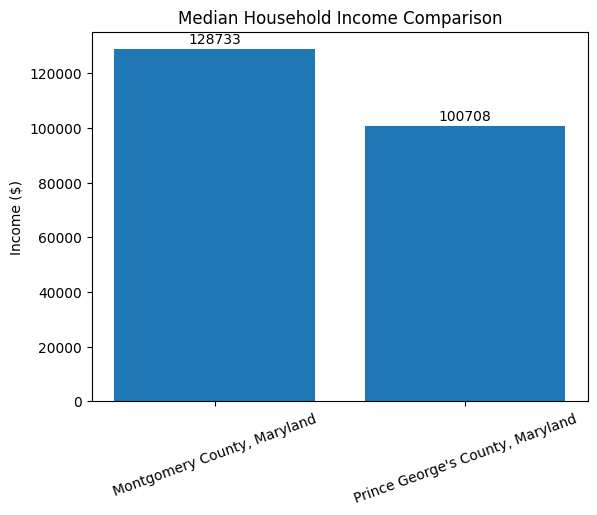

In [31]:
import matplotlib.pyplot as plt

# Improved bar chart with labels

plt.figure()

bars = plt.bar(target["NAME"], target["Median_Income"])

plt.title("Median Household Income Comparison")
plt.ylabel("Income ($)")
plt.xticks(rotation=20)

# Add values on top of bars
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 2000, f"{int(y)}", ha='center')

plt.show()

Montgomery County has a higher median household income (about $128,000) compared to Prince George’s County (about $100,000). This shows a clear economic difference between the two counties.

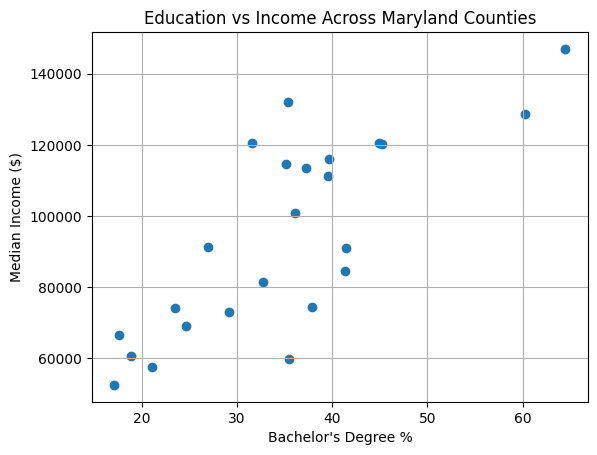

In [32]:
# Scatter plot using ALL counties

plt.figure()

plt.scatter(
    df["Bachelors_Percent"],
    df["Median_Income"]
)

plt.xlabel("Bachelor's Degree %")
plt.ylabel("Median Income ($)")
plt.title("Education vs Income Across Maryland Counties")

plt.grid()

plt.show()

This scatter plot shows the relationship between education and income across all Maryland counties. There is a clear upward trend, meaning that counties with higher percentages of residents holding bachelor’s degrees tend to have higher median household incomes. This suggests a positive relationship between education level and income.

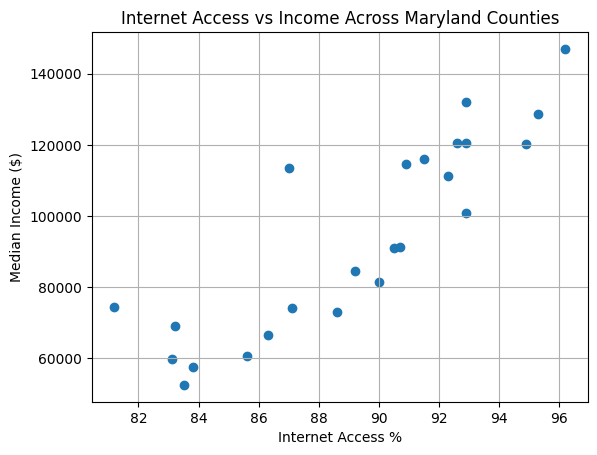

In [33]:
# Internet vs Income

plt.figure()

plt.scatter(
    df["Internet_Access_Percent"],
    df["Median_Income"]
)

plt.xlabel("Internet Access %")
plt.ylabel("Median Income ($)")
plt.title("Internet Access vs Income Across Maryland Counties")

plt.grid()

plt.show()

This scatter plot shows the relationship between internet access and income across Maryland counties. There is a clear upward trend, indicating that counties with higher internet access tend to have higher median household incomes. This suggests that access to technology may be linked to better economic opportunities and higher income levels.

Overall, the analysis shows that education, internet access, and income are closely related. Counties with higher education levels and better internet access tend to have higher median household incomes. This suggests that both education and access to technology play an important role in economic outcomes across Maryland counties.

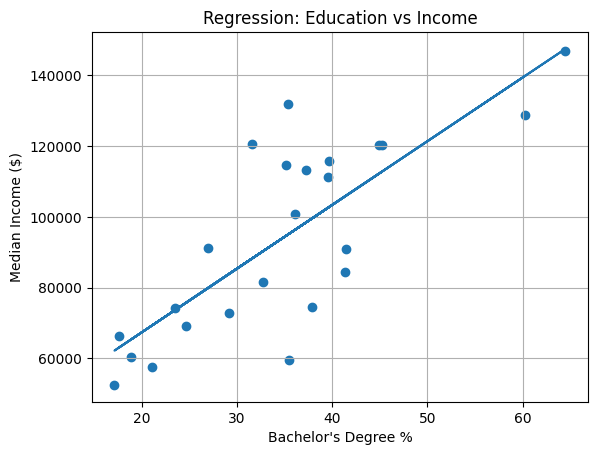

Slope: 1800.2333717434267
Intercept: 31383.988105212524


In [34]:
# Simple regression: Education → Income

import numpy as np

# X = education, y = income
x = df["Bachelors_Percent"]
y = df["Median_Income"]

# Fit line
m, b = np.polyfit(x, y, 1)

# Plot
plt.figure()
plt.scatter(x, y)

# regression line
plt.plot(x, m*x + b)

plt.xlabel("Bachelor's Degree %")
plt.ylabel("Median Income ($)")
plt.title("Regression: Education vs Income")

plt.grid()
plt.show()

# Print equation
print("Slope:", m)
print("Intercept:", b)

A regression analysis was performed to examine the relationship between education and income. The results show a positive slope of approximately 1800, meaning that for every 1% increase in the percentage of residents with a bachelor’s degree, median household income increases by about $1,800. This confirms a strong positive relationship between education and income across Maryland counties.

In the regression model, the intercept (b) is approximately 31,383. This represents the estimated median income when the percentage of residents with a bachelor’s degree is zero. While this value may not be realistic in practice, it is part of the regression equation used to model the relationship between education and income.

In [35]:
# Correlation
corr = df["Bachelors_Percent"].corr(df["Median_Income"])
print("Correlation:", corr)

Correlation: 0.7816288020850959


The correlation coefficient is approximately 0.78, indicating a strong positive relationship between education and income. This means that counties with higher percentages of residents holding bachelor’s degrees tend to have higher median household incomes.

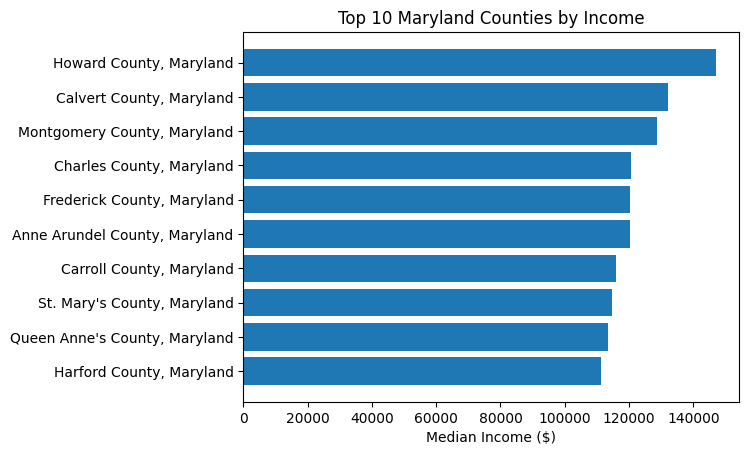

In [36]:
# Top counties by income

top = df.sort_values("Median_Income", ascending=False).head(10)

plt.figure()
plt.barh(top["NAME"], top["Median_Income"])

plt.xlabel("Median Income ($)")
plt.title("Top 10 Maryland Counties by Income")

plt.gca().invert_yaxis()
plt.show()

This chart shows the top 10 Maryland counties by median household income. Howard County has the highest median income, followed by Calvert and Montgomery counties. Most of the top counties are located in central Maryland, suggesting that income levels are higher in areas closer to major economic centers. This highlights geographic differences in income across the state.

In conclusion, this analysis shows that there is a strong positive relationship between education and income across Maryland counties. Counties with higher percentages of residents holding bachelor’s degrees tend to have higher median household incomes. Internet access also shows a positive relationship with income, indicating that more developed areas have better access to technology.

When comparing Montgomery County and Prince George’s County, Montgomery County has higher income, higher education levels, and slightly higher internet access. This suggests differences in economic development between the two counties.

Overall, the results demonstrate how education and access to resources are important factors in understanding income differences across regions.

# Further Analysis (Beyond EDA)
In this section, I expand the analysis to include all 24 Maryland counties.
This includes grouping counties, statistical testing, regression models, and clustering.

Grouping counties into regions for analysis

In [37]:
df.columns

Index(['NAME', 'Median_Income', 'Population', 'Bachelors_Percent',
       'Internet_Access_Percent'],
      dtype='object')

In [38]:
df = df.rename(columns={"NAME": "County"})

In [40]:
df["County"] = df["County"].str.replace(", Maryland", "", regex=False)

In [41]:
def county_group(county):
    washington_metro = ["Montgomery County", "Prince George's County", "Frederick County"]
    baltimore_metro = ["Baltimore County", "Baltimore City", "Anne Arundel County", "Howard County", "Harford County", "Carroll County"]
    eastern_shore = ["Cecil County", "Kent County", "Queen Anne's County", "Talbot County", "Caroline County",
                     "Dorchester County", "Wicomico County", "Somerset County", "Worcester County"]
    western_md = ["Garrett County", "Allegany County", "Washington County"]

    if county in washington_metro:
        return "Washington Metro"
    elif county in baltimore_metro:
        return "Baltimore Metro"
    elif county in eastern_shore:
        return "Eastern Shore"
    elif county in western_md:
        return "Western Maryland"
    else:
        return "Other Maryland"

df["County_Group"] = df["County"].apply(county_group)

df[["County", "County_Group"]].head()

,County,County_Group
0,Allegany County,Western Maryland
1,Anne Arundel County,Baltimore Metro
2,Baltimore County,Baltimore Metro
3,Calvert County,Other Maryland
4,Caroline County,Eastern Shore


Comparing median income across different county groups

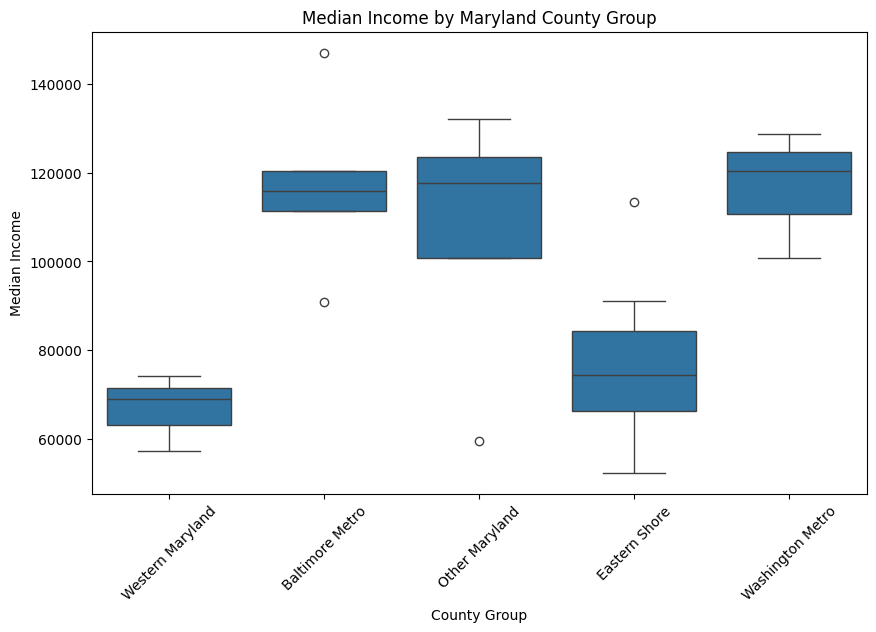

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="County_Group", y="Median_Income")
plt.xticks(rotation=45)
plt.title("Median Income by Maryland County Group")
plt.xlabel("County Group")
plt.ylabel("Median Income")
plt.show()

Testing whether income differences between county groups are statistically significant

In [43]:
from scipy.stats import f_oneway

groups = [group["Median_Income"].dropna() for name, group in df.groupby("County_Group")]

anova_result = f_oneway(*groups)

print("ANOVA p-value:", anova_result.pvalue)

ANOVA p-value: 0.0033866096050226965


The ANOVA test was used to determine whether there are statistically significant differences in median income across Maryland county groups. The p-value is approximately 0.003, which is less than 0.05. This indicates that there are statistically significant differences in median income between at least some of the county groups. This suggests that location and regional grouping are important factors when analyzing income across Maryland counties.

Comparing Montgomery County, Prince George’s County, and the rest of Maryland

In [44]:
def comparison_group(county):
    if county == "Montgomery County":
        return "Montgomery County"
    elif county == "Prince George's County":
        return "Prince George's County"
    else:
        return "Rest of Maryland"

df["Comparison_Group"] = df["County"].apply(comparison_group)

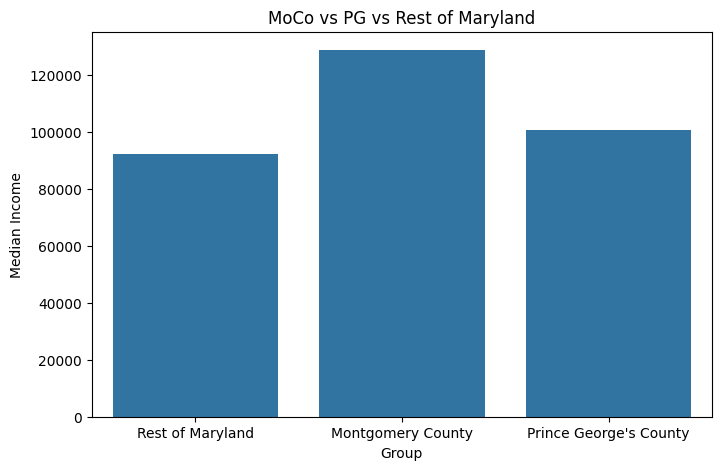

In [45]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Comparison_Group", y="Median_Income", errorbar=None)
plt.title("MoCo vs PG vs Rest of Maryland")
plt.xlabel("Group")
plt.ylabel("Median Income")
plt.show()

This chart compares Montgomery County and Prince George’s County with the rest of Maryland. While the earlier analysis focused on all counties, this view highlights how these two counties compare to the broader state. This helps connect the original project focus with the expanded statewide analysis.

Analyzing the relationship between income, education, and internet access

In [46]:
corr = df[["Median_Income", "Bachelors_Percent", "Internet_Access_Percent"]].corr()

print(corr)

                         Median_Income  Bachelors_Percent  \
Median_Income                 1.000000           0.781629   
Bachelors_Percent             0.781629           1.000000   
Internet_Access_Percent       0.872487           0.686781   

                         Internet_Access_Percent  
Median_Income                           0.872487  
Bachelors_Percent                       0.686781  
Internet_Access_Percent                 1.000000  


The correlation analysis shows a strong positive relationship between median income and educational attainment (correlation ≈ 0.78). This suggests that counties with higher levels of bachelor’s degree attainment tend to have higher median income.

There is also a very strong positive relationship between median income and internet access (correlation ≈ 0.87). This indicates that counties with better internet access tend to have higher income levels.

Overall, the results suggest that both education and internet access are strongly associated with income across Maryland counties, with internet access showing an even stronger relationship.

Using regression models to predict income based on education and internet access

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[["Bachelors_Percent", "Internet_Access_Percent"]]
y = df["Median_Income"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("R-squared:", r2_score(y, y_pred))
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

R-squared: 0.8242201249947905
Coefficients: [ 795.2358788  4076.49050764]
Intercept: -297435.8478690191


This project began by comparing Montgomery County and Prince George’s County, but it was expanded to include all 24 Maryland counties to provide a more comprehensive analysis. The results show that there are statistically significant differences in income across county groups, as confirmed by the ANOVA test.

The correlation analysis revealed strong positive relationships between income, education, and internet access, with internet access showing the strongest association. The regression model further confirmed that these variables are strong predictors of income, explaining over 80% of the variation.

Overall, the analysis demonstrates that regional differences, educational attainment, and access to technology play an important role in shaping income levels across Maryland counties. While some methods showed strong relationships, others provided less clear results, which is also valuable in understanding the data.

Visualizing the relationship between education and income

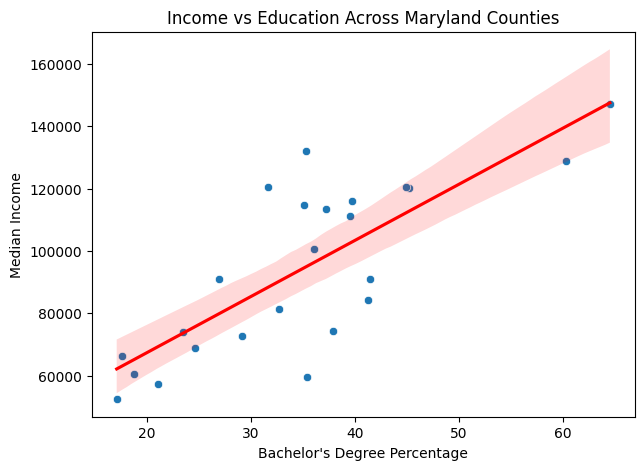

In [48]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Bachelors_Percent", y="Median_Income")

# regression line
sns.regplot(data=df, x="Bachelors_Percent", y="Median_Income", scatter=False, color='red')

plt.title("Income vs Education Across Maryland Counties")
plt.xlabel("Bachelor's Degree Percentage")
plt.ylabel("Median Income")
plt.show()

This scatter plot shows the relationship between educational attainment and median income across Maryland counties. The upward trend and regression line indicate that counties with higher levels of education tend to have higher income levels. This supports the correlation and regression results shown earlier.

Limitations and Methodological Considerations

Some initial analyses focused only on comparing Montgomery County and Prince George’s County. However, this approach did not provide strong or statistically meaningful results because it did not use enough data points.

This led to expanding the analysis to include all Maryland counties, which allowed for more reliable statistical testing, correlation analysis, and regression modeling. This highlights the importance of using a broader dataset when performing data analysis.